Phase 1 — Problem Definition
Objective
Classification problem: features X, target y.

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [149]:
df = pd.read_excel('../data/default+of+credit+card+clients/default of credit card clients.xls', engine='xlrd', index_col=0, header=1 )


Phase 2 — Data Exploration
Objective
Distribution, missing values, categorical variables, class imbalance.

In [150]:
print(df.head())

    LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
ID                                                                         
1       20000    2          2         1   24      2      2     -1     -1   
2      120000    2          2         2   26     -1      2      0      0   
3       90000    2          2         2   34      0      0      0      0   
4       50000    2          2         1   37      0      0      0      0   
5       50000    1          2         1   57     -1      0     -1      0   

    PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
ID         ...                                                                  
1      -2  ...          0          0          0         0       689         0   
2       0  ...       3272       3455       3261         0      1000      1000   
3       0  ...      14331      14948      15549      1518      1500      1000   
4       0  ...      28314      28959      29547      2000     

In [151]:
print(df.shape)

(30000, 24)


In [152]:
print(df.columns)


Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')


In [153]:
print(df.isna().sum())

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [154]:
print(df.describe().T)

                              count           mean            std       min  \
LIMIT_BAL                   30000.0  167484.322667  129747.661567   10000.0   
SEX                         30000.0       1.603733       0.489129       1.0   
EDUCATION                   30000.0       1.853133       0.790349       0.0   
MARRIAGE                    30000.0       1.551867       0.521970       0.0   
AGE                         30000.0      35.485500       9.217904      21.0   
PAY_0                       30000.0      -0.016700       1.123802      -2.0   
PAY_2                       30000.0      -0.133767       1.197186      -2.0   
PAY_3                       30000.0      -0.166200       1.196868      -2.0   
PAY_4                       30000.0      -0.220667       1.169139      -2.0   
PAY_5                       30000.0      -0.266200       1.133187      -2.0   
PAY_6                       30000.0      -0.291100       1.149988      -2.0   
BILL_AMT1                   30000.0   51223.330900  

In [155]:
print(df['default payment next month'].value_counts())

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [156]:
print(df['SEX'].value_counts())
print(df['SEX'].value_counts(normalize=True))

SEX
2    18112
1    11888
Name: count, dtype: int64
SEX
2    0.603733
1    0.396267
Name: proportion, dtype: float64


In [157]:
print(df["EDUCATION"].value_counts())
print(df["EDUCATION"].value_counts(normalize=True)*100)

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
EDUCATION
2    46.766667
1    35.283333
3    16.390000
5     0.933333
4     0.410000
6     0.170000
0     0.046667
Name: proportion, dtype: float64


In [158]:
print(df["MARRIAGE"].value_counts())
print(df["MARRIAGE"].value_counts(normalize=True)*100)

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
MARRIAGE
2    53.213333
1    45.530000
3     1.076667
0     0.180000
Name: proportion, dtype: float64


Phase 3 — EDA
Objective
Credit limits, age, repayment history, bills, payments, correlations.

In [159]:
def_rate_by_edu= df.groupby("EDUCATION")['default payment next month'].mean().sort_values(ascending=False) * 100
print(def_rate_by_edu)

EDUCATION
3    25.157616
2    23.734854
1    19.234766
6    15.686275
5     6.428571
4     5.691057
0     0.000000
Name: default payment next month, dtype: float64


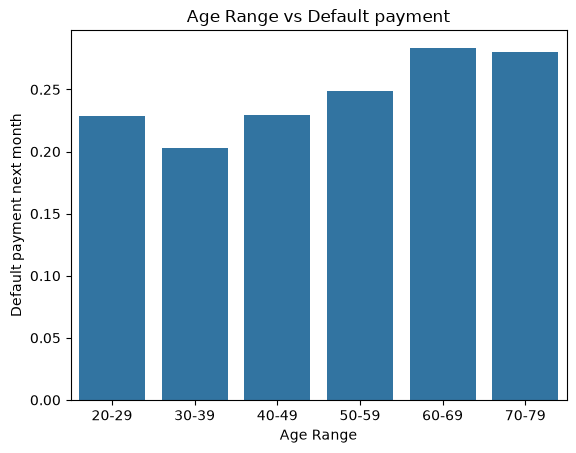

In [160]:
bins= [20, 30, 40, 50 , 60, 70 ,80]
labels= ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['age_range']= pd.cut(df["AGE"], bins=bins, labels=labels, right=False )


sns.barplot(data=df, 
            x='age_range',
            y='default payment next month' ,
            order=labels,
            errorbar=None )

plt.xlabel("Age Range")
plt.ylabel("Default payment next month")
plt.title("Age Range vs Default payment")

plt.show()


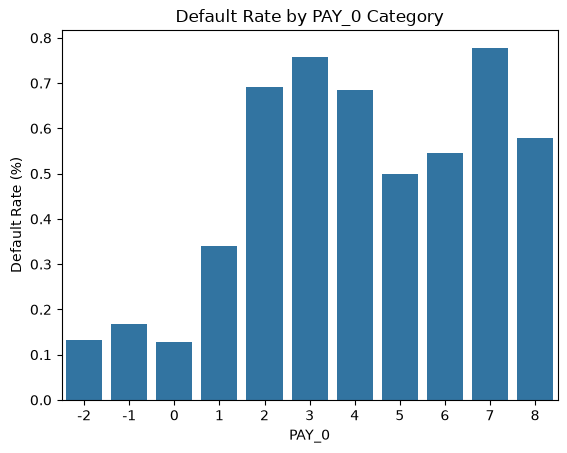

In [161]:
sns.barplot(data=df,
            x="PAY_0", 
            y="default payment next month", 
            order=sorted(df['PAY_0']),
            errorbar=None )

plt.xlabel('PAY_0')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by PAY_0 Category')

plt.show()

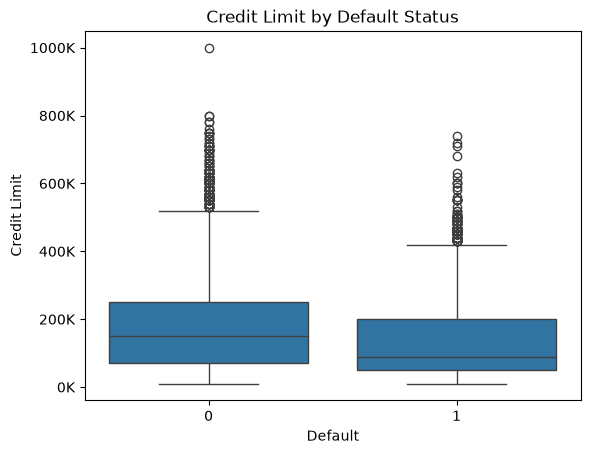

In [162]:
from matplotlib.ticker import FuncFormatter
sns.boxplot(
    data=df,
    x="default payment next month",
    y="LIMIT_BAL"
)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.title("Credit Limit by Default Status")
plt.show()

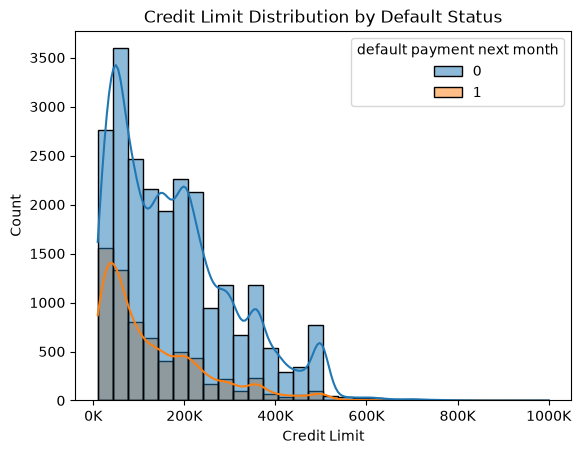

In [163]:
from matplotlib.ticker import FuncFormatter
sns.histplot(
    data=df,
    x="LIMIT_BAL",
    hue="default payment next month",
    bins=30,
    kde=True
)
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Credit Limit")
plt.title("Credit Limit Distribution by Default Status")
plt.show()

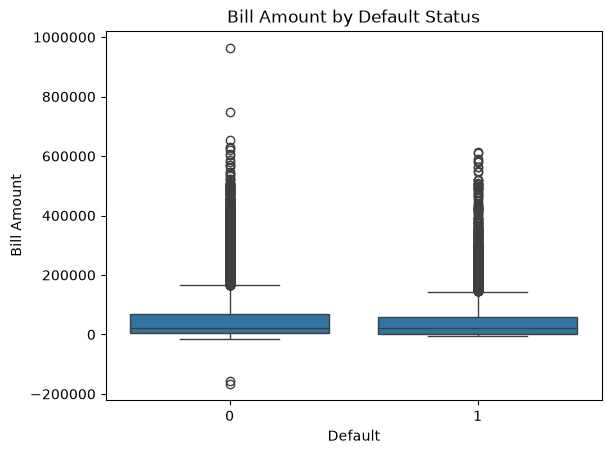

In [164]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="BILL_AMT1"
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Default")
plt.ylabel("Bill Amount")
plt.title("Bill Amount by Default Status")
plt.show()

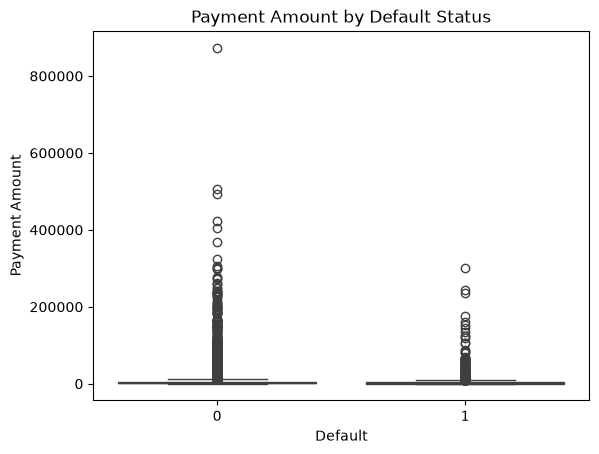

In [165]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="PAY_AMT1"
)

plt.xlabel("Default")
plt.ylabel("Payment Amount")
plt.title("Payment Amount by Default Status")
plt.show()

************************************************************************
--------------------------Correlation Analysis-------------------------
************************************************************************

In [166]:
corr= df.corr(numeric_only=True)
corr['default payment next month'].sort_values(ascending=False) * 100



default payment next month    100.000000
PAY_0                          32.479373
PAY_2                          26.355120
PAY_3                          23.525251
PAY_4                          21.661364
PAY_5                          20.414891
PAY_6                          18.686636
EDUCATION                       2.800608
AGE                             1.388983
BILL_AMT6                      -0.537231
BILL_AMT5                      -0.676046
BILL_AMT4                      -1.015650
BILL_AMT3                      -1.407552
BILL_AMT2                      -1.419322
BILL_AMT1                      -1.964420
MARRIAGE                       -2.433922
SEX                            -3.996058
PAY_AMT6                       -5.318334
PAY_AMT5                       -5.512352
PAY_AMT3                       -5.625035
PAY_AMT4                       -5.682740
PAY_AMT2                       -5.857871
PAY_AMT1                       -7.292949
LIMIT_BAL                     -15.351988
Name: default pa

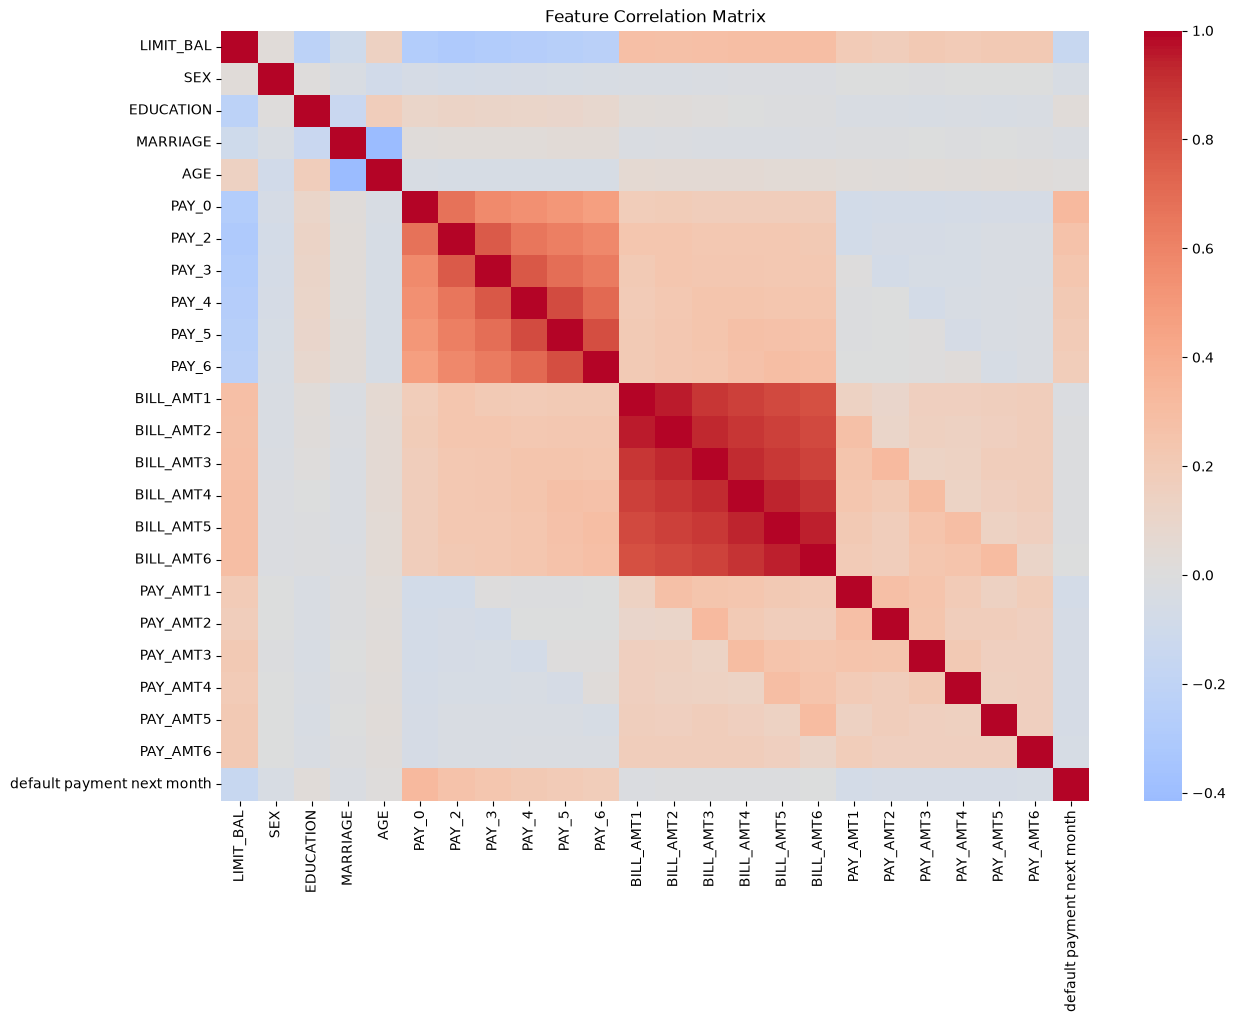

In [167]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

Phase 4 — Preprocessing
Objective
Scaling, one-hot encoding, ColumnTransformer, pipelines.

************************************************************************
--------------------------Data Preparation-------------------------
************************************************************************

In [168]:
#Choosing Feautures

X= df.drop(columns=["default payment next month", "age_range"])
y= df['default payment next month']


In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64

In [170]:
#Defining Feauture groups

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numerical_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

Phase 5 — Baseline & Models
Objective
Dummy classifier → Logistic Regression → Decision Tree → Random Forest.

In [171]:
#Preprocessing Data

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor= ColumnTransformer(
    transformers= [("num", StandardScaler(), numerical_features),
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

pipeline= Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred= pipeline.predict(X_test)

In [172]:
from sklearn.metrics import accuracy_score

baseline_pred = [0] * len(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Dummy Baseline Accuracy: {baseline_accuracy:.4f}")


Dummy Baseline Accuracy: 0.7788


In [173]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


Accuracy: 0.8168333333333333
Precision: 0.6614730878186968
Recall: 0.3519216277317257
F1: 0.45941957697983277
[[4434  239]
 [ 860  467]]


************************************************************************
--------------------Model Comparision-------------------------
************************************************************************

In [174]:
from sklearn.tree import DecisionTreeClassifier

tree_model= Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

tree_model.fit(X_train, y_train)
tree_pred= tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1:", f1_score(y_test, tree_pred))

Accuracy: 0.7215
Precision: 0.3778409090909091
Recall: 0.400904295403165
F1: 0.38903107861060326


In [175]:
#Detect Overfitting

tree_train_pred = tree_model.predict(X_train)

print(
    "Training accuracy:",
    accuracy_score(y_train, tree_train_pred)
)

print(
    "Test accuracy:",
    accuracy_score(y_test, tree_pred)
)

Training accuracy: 0.9994583333333333
Test accuracy: 0.7215


In [176]:
#checking out tree depth

tree_model.named_steps["classifier"].get_depth()
tree_model.named_steps["classifier"].get_n_leaves()

np.int64(3797)

In [177]:
#Controlling the tree's complexity

depths = [3, 5, 8, 10, 15, 20, 30]

for depth in depths:
    tree_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    tree_model.fit(X_train, y_train)

    train_pred = tree_model.predict(X_train)
    test_pred = tree_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        f"Depth: {depth:2} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )


Depth:  3 | Train: 0.8195 | Test: 0.8162
Depth:  5 | Train: 0.8241 | Test: 0.8153
Depth:  8 | Train: 0.8358 | Test: 0.8117
Depth: 10 | Train: 0.8491 | Test: 0.8075
Depth: 15 | Train: 0.8932 | Test: 0.7875
Depth: 20 | Train: 0.9368 | Test: 0.7642
Depth: 30 | Train: 0.9900 | Test: 0.7280


Even at its best decision tree couldnt beat logistic regression

                    Logistic    Tree depth 8
Accuracy              81.68%        81.17%
Precision             66.15%        64.46%
Recall                35.19%        33.08%
F1                    45.94%        43.73%

Random Forest
Objective

Use an ensemble of decision trees to obtain a more robust model and see whether combining many trees improves our predictions.

Concepts 

- Ensemble learning
- Random Forest
- Bootstrap sampling
- Feature randomness
- Bias/variance
- Overfitting reduction

In [178]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [179]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8143333333333334
Precision: 0.6441136671177267
Recall: 0.35870384325546345
F1: 0.46079380445304935

Confusion Matrix:
[[4410  263]
 [ 851  476]]


Phase 6 — Model Optimization
Objective
Hyperparameter tuning + cross-validation + threshold selection.

Probability and Decision Thresholds
Objective

Understand how a classification model converts probabilities into class predictions and how changing the threshold affects precision and recall.

Concepts
- predict_proba()
- Classification threshold
- Precision–recall tradeoff
- Business decision-making

In [180]:
rf_default_prob = rf_model.predict_proba(X_test)[:, 1]


Find the Best Threshold
Objective

Instead of arbitrarily choosing 0.30, investigate how model performance changes across many thresholds and choose a threshold based on an explicit criterion.

Concepts
- Threshold tuning
- Precision–recall tradeoff
- F1 optimization
- Model evaluation

In [181]:

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:
    predictions = (rf_default_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.273 | Recall: 0.898 | F1: 0.419
Threshold: 0.15 | Precision: 0.324 | Recall: 0.763 | F1: 0.455
Threshold: 0.20 | Precision: 0.385 | Recall: 0.671 | F1: 0.489
Threshold: 0.25 | Precision: 0.446 | Recall: 0.595 | F1: 0.510
Threshold: 0.30 | Precision: 0.501 | Recall: 0.542 | F1: 0.521
Threshold: 0.35 | Precision: 0.547 | Recall: 0.497 | F1: 0.521
Threshold: 0.40 | Precision: 0.587 | Recall: 0.457 | F1: 0.514
Threshold: 0.45 | Precision: 0.617 | Recall: 0.411 | F1: 0.493
Threshold: 0.50 | Precision: 0.644 | Recall: 0.359 | F1: 0.461
Threshold: 0.55 | Precision: 0.673 | Recall: 0.311 | F1: 0.426
Threshold: 0.60 | Precision: 0.694 | Recall: 0.267 | F1: 0.385
Threshold: 0.65 | Precision: 0.711 | Recall: 0.209 | F1: 0.324
Threshold: 0.70 | Precision: 0.718 | Recall: 0.151 | F1: 0.250
Threshold: 0.75 | Precision: 0.780 | Recall: 0.107 | F1: 0.188
Threshold: 0.80 | Precision: 0.798 | Recall: 0.063 | F1: 0.116
Threshold: 0.85 | Precision: 0.849 | Recall: 0.034 | F1

Cross-Validation & Hyperparameter Tuning
Objective

Find a model configuration that generalizes well without making decisions based on our test set.

Concepts
- Cross-validation
- Validation data
- Hyperparameter tuning
- GridSearchCV
- Generalization
- Data leakage

The basic idea is:

                  Training data
                       │
             ┌─────────┴─────────┐
             ↓                   ↓
        Cross-validation     Final test set
             │                   │
       model selection        untouched
             │                   │
             ↓                   │
       Final model ──────────────┘
                       ↓
                 Final evaluation

Instead of relying on one split, cross-validation repeatedly divides the training data.

In [182]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [183]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_leaf": [1, 5, 10]
}

In [184]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)

In [ ]:
#Final Test Evaluation of the Tuned Model

best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, best_pred))
print("Test Precision:", precision_score(y_test, best_pred))
print("Test Recall:", recall_score(y_test, best_pred))
print("Test F1:", f1_score(y_test, best_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

Validation Set for Threshold Selection
Objective

Choose the classification threshold without touching the final test set.

Concepts
- Training / validation / test sets
- Threshold tuning
- Data leakage
- Nested decision-making

Currently we have:

Training → model fitting + cross-validation
Test     → final evaluation

We need somewhere to experiment with thresholds.

We could create:

Training 
   ↓

Train + Validation


Test
   ↓
Final evaluation

For simplicity, we'll make a validation split from our existing training data.

In [187]:
from sklearn.model_selection import train_test_split

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [188]:
final_selection_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,  # hyperparameters selected by grid search (5-fold CV, scoring='f1')
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

final_selection_model.fit(X_train_model, y_train_model)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [189]:
val_prob = final_selection_model.predict_proba(X_val)[:, 1]

In [190]:
thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.280 | Recall: 0.917 | F1: 0.429
Threshold: 0.15 | Precision: 0.340 | Recall: 0.807 | F1: 0.479
Threshold: 0.20 | Precision: 0.404 | Recall: 0.696 | F1: 0.512
Threshold: 0.25 | Precision: 0.465 | Recall: 0.608 | F1: 0.527
Threshold: 0.30 | Precision: 0.516 | Recall: 0.551 | F1: 0.533
Threshold: 0.35 | Precision: 0.562 | Recall: 0.508 | F1: 0.534
Threshold: 0.40 | Precision: 0.594 | Recall: 0.459 | F1: 0.518
Threshold: 0.45 | Precision: 0.628 | Recall: 0.426 | F1: 0.507
Threshold: 0.50 | Precision: 0.655 | Recall: 0.381 | F1: 0.482
Threshold: 0.55 | Precision: 0.671 | Recall: 0.328 | F1: 0.440
Threshold: 0.60 | Precision: 0.707 | Recall: 0.278 | F1: 0.399
Threshold: 0.65 | Precision: 0.738 | Recall: 0.218 | F1: 0.336
Threshold: 0.70 | Precision: 0.745 | Recall: 0.152 | F1: 0.252
Threshold: 0.75 | Precision: 0.721 | Recall: 0.088 | F1: 0.156
Threshold: 0.80 | Precision: 0.774 | Recall: 0.045 | F1: 0.085
Threshold: 0.85 | Precision: 0.632 | Recall: 0.011 | F1

Final Model Evaluation

Objective

Evaluate our complete modeling pipeline on data that has never been used for model selection or threshold selection.

In [191]:
test_prob = final_selection_model.predict_proba(X_test)[:, 1]

In [192]:
final_threshold = 0.35

final_pred = (test_prob >= final_threshold).astype(int)

In [193]:
print("Final Accuracy:", accuracy_score(y_test, final_pred))
print("Final Precision:", precision_score(y_test, final_pred))
print("Final Recall:", recall_score(y_test, final_pred))
print("Final F1:", f1_score(y_test, final_pred))

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy: 0.8001666666666667
Final Precision: 0.5516962843295639
Final Recall: 0.5146948003014318
Final F1: 0.5325536062378168

Final Confusion Matrix:
[[4118  555]
 [ 644  683]]


Phase 7 — Model Interpretation
Objective
Feature importance + permutation importance.

Model Interpretation
Objective

Understand why the model makes its predictions and identify which customer characteristics are most useful for predicting default.

Concepts
- Feature importance
- Model interpretability
- Feature effects
- Correlation vs predictive importance

In [194]:
feature_importance = pd.Series(
    final_selection_model["classifier"].feature_importances_,
    index=final_selection_model["preprocessor"].get_feature_names_out()
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(15))

num__AGE          0.063019
num__LIMIT_BAL    0.061663
num__BILL_AMT1    0.056210
cat__PAY_0_2      0.055420
num__BILL_AMT2    0.051168
num__BILL_AMT3    0.048419
num__BILL_AMT6    0.048149
num__BILL_AMT4    0.047728
num__PAY_AMT1     0.047564
num__BILL_AMT5    0.047526
num__PAY_AMT2     0.045329
num__PAY_AMT3     0.043343
num__PAY_AMT6     0.042899
num__PAY_AMT5     0.041210
num__PAY_AMT4     0.040434
dtype: float64


Permutation Importance
Objective

Measure how much the model's performance decreases when we randomly shuffle one feature.

In [195]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_selection_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


In [196]:
perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance.head(15))


PAY_0        0.158159
PAY_2        0.031505
PAY_AMT2     0.019404
PAY_AMT1     0.018247
BILL_AMT1    0.017951
PAY_3        0.015938
PAY_6        0.015562
LIMIT_BAL    0.014359
PAY_AMT6     0.012090
PAY_5        0.011644
BILL_AMT2    0.011601
PAY_AMT3     0.009740
PAY_AMT5     0.008712
PAY_4        0.008586
BILL_AMT5    0.007958
dtype: float64


Phase 8 — Evaluation
Objective
Confusion matrix + ROC-AUC + Precision-Recall + Average Precision.

Model Performance Curves
Objective

Evaluate our classifier across all possible probability thresholds, rather than judging it at just one threshold.

Concepts
- ROC curve
- ROC-AUC
- Precision-Recall curve
- Threshold-independent evaluation
- Class imbalance

In [197]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, test_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7558900712473698


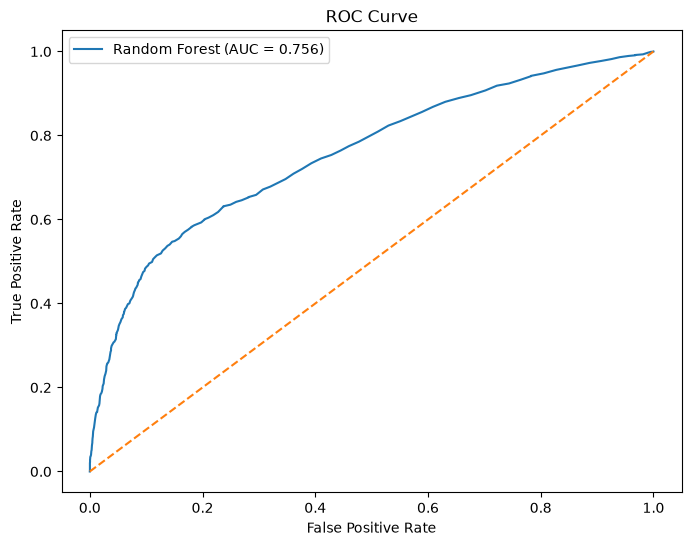

In [198]:
fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Precision-Recall Curve
Objective

Evaluate how well the model identifies the minority class (defaulters) across different thresholds.

In [199]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_prob
)

average_precision = average_precision_score(y_test, test_prob)

print("Average Precision:", average_precision)

Average Precision: 0.5341111696902321


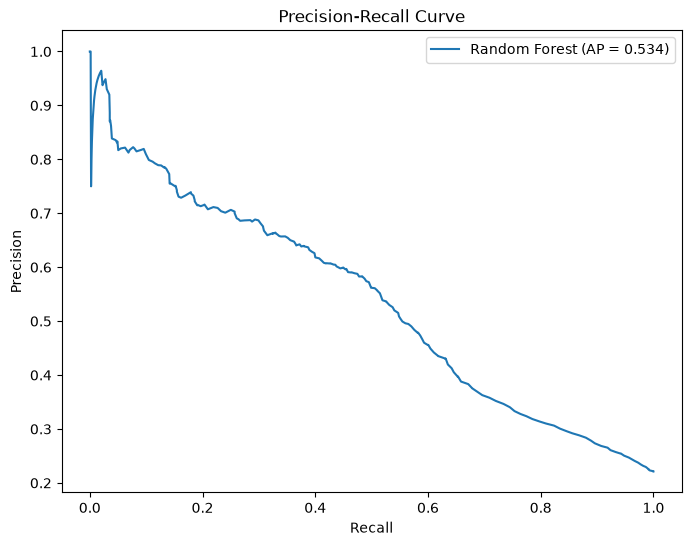

In [200]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Model Interpretation & Visualization
Objective

Turn our numerical results into something a human can understand and communicate.

Concepts
- Feature importance visualization
- Model interpretation
- Confusion matrix visualization
- ROC/PR curves
- Communicating ML results

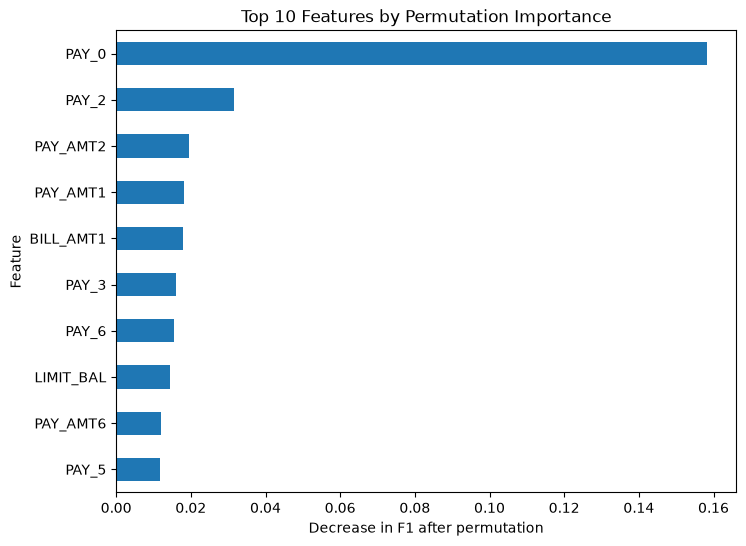

In [201]:
top_features = perm_importance.head(10).sort_values()

plt.figure(figsize=(8, 6))

top_features.plot(kind="barh")

plt.xlabel("Decrease in F1 after permutation")
plt.ylabel("Feature")
plt.title("Top 10 Features by Permutation Importance")

plt.show()

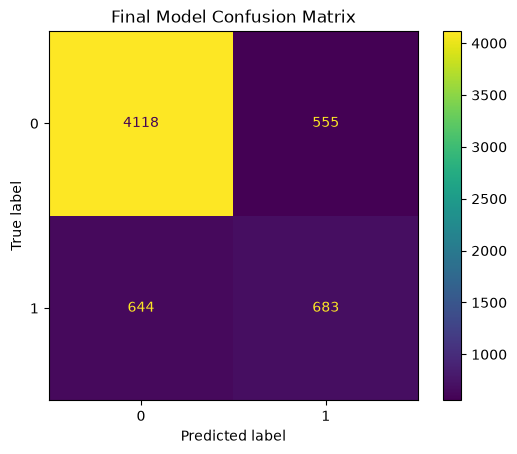

In [202]:
#Visualizaing Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred
)

plt.title("Final Model Confusion Matrix")
plt.show()

Phase 9 — Error Analysis
Objective
False positives, false negatives, borderline predictions.

Error Analysis
Objective

Understand the mistakes made by our final model and determine whether there are recognizable patterns among those mistakes.

Concepts
- False positives and false negatives
- Error analysis
- Model limitations
- Investigating difficult examples
- Connecting model behavior to the real-world problem

In [203]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = final_pred
error_analysis["probability"] = test_prob

In [204]:
def classify_result(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    elif row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"


error_analysis["result"] = error_analysis.apply(
    classify_result,
    axis=1
)



In [205]:
print(error_analysis["result"].value_counts())

result
True Negative     4118
True Positive      683
False Negative     644
False Positive     555
Name: count, dtype: int64


In [206]:
#Inspect the false negatives

false_negatives = error_analysis[
    error_analysis["result"] == "False Negative"
]

print(false_negatives.describe())

           LIMIT_BAL         SEX   EDUCATION    MARRIAGE         AGE  \
count     644.000000  644.000000  644.000000  644.000000  644.000000   
mean   160652.173913    1.590062    1.881988    1.504658   35.990683   
std    122763.197350    0.492204    0.765743    0.524643    9.194625   
min     10000.000000    1.000000    1.000000    1.000000   22.000000   
25%     50000.000000    1.000000    1.000000    1.000000   28.000000   
50%    130000.000000    2.000000    2.000000    1.000000   35.000000   
75%    230000.000000    2.000000    2.000000    2.000000   42.000000   
max    550000.000000    2.000000    6.000000    3.000000   70.000000   

            PAY_0       PAY_2       PAY_3       PAY_4       PAY_5  ...  \
count  644.000000  644.000000  644.000000  644.000000  644.000000  ...   
mean    -0.324534   -0.459627   -0.445652   -0.472050   -0.467391  ...   
std      0.837656    0.952977    1.050141    1.062946    1.067194  ...   
min     -2.000000   -2.000000   -2.000000   -2.000000  

In [207]:
#Inspect the true positives

true_positives = error_analysis[
    error_analysis["result"] == "True Positive"
]

print(true_positives.describe())

           LIMIT_BAL         SEX   EDUCATION    MARRIAGE         AGE  \
count     683.000000  683.000000  683.000000  683.000000  683.000000   
mean   115823.836018    1.565154    1.922401    1.506589   36.033675   
std    113028.291857    0.496100    0.688071    0.511911   10.097779   
min     10000.000000    1.000000    1.000000    1.000000   21.000000   
25%     30000.000000    1.000000    1.000000    1.000000   27.000000   
50%     70000.000000    2.000000    2.000000    2.000000   35.000000   
75%    160000.000000    2.000000    2.000000    2.000000   43.000000   
max    600000.000000    2.000000    4.000000    3.000000   73.000000   

            PAY_0       PAY_2       PAY_3       PAY_4       PAY_5  ...  \
count  683.000000  683.000000  683.000000  683.000000  683.000000  ...   
mean     1.540264    1.285505    1.074671    0.909224    0.837482  ...   
std      1.279000    1.448696    1.561633    1.730514    1.724823  ...   
min     -2.000000   -2.000000   -2.000000   -2.000000  

In [208]:
#Let's explicitly look at customers around our threshold.
borderline = error_analysis[
    (error_analysis["probability"] >= 0.25) &
    (error_analysis["probability"] <= 0.45)
]

print(borderline["result"].value_counts())

result
True Negative     429
False Positive    200
True Positive     132
False Negative    119
Name: count, dtype: int64


## Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Dummy Classifier | 77.88% | — | — | — |
| Logistic Regression | 81.68% | 66.15% | 35.19% | 45.94% |
| Decision Tree | 81.43% | 64.41% | 35.87% | 46.08% |
| Random Forest | 81.65% | 65.03% | 36.85% | 47.04% |
| Random Forest (Threshold = 0.35) | 80.02% | 55.17% | 51.47% | **53.26%** |

### Model Selection

The threshold-tuned Random Forest was selected as the final model. Although
its accuracy is slightly lower than the Random Forest using the default
0.50 threshold, lowering the threshold to 0.35 substantially increased
recall from 36.85% to 51.47% and improved the F1 score from 47.04% to
53.26%.

This trade-off is important for credit default prediction because missing
an actual defaulter (false negative) can be more costly than incorrectly
flagging a customer as risky (false positive).